# Download dataset

In [1]:
!gdown 1kUy2tuH-kKBlFCNA0a9sqD2TG4uyvBnV

Downloading...
From (original): https://drive.google.com/uc?id=1kUy2tuH-kKBlFCNA0a9sqD2TG4uyvBnV
From (redirected): https://drive.google.com/uc?id=1kUy2tuH-kKBlFCNA0a9sqD2TG4uyvBnV&confirm=t&uuid=bdd6d680-9f93-4031-9a2b-52b7a38bbce7
To: /content/icdar2003.zip
100% 45.7M/45.7M [00:01<00:00, 28.5MB/s]


In [2]:
!unzip "/content/icdar2003.zip"

Archive:  /content/icdar2003.zip
   creating: SceneTrialTrain/apanar_06.08.2002/
  inflating: SceneTrialTrain/apanar_06.08.2002/IMG_1247.JPG  
  inflating: SceneTrialTrain/apanar_06.08.2002/IMG_1252.JPG  
  inflating: SceneTrialTrain/apanar_06.08.2002/IMG_1253.JPG  
  inflating: SceneTrialTrain/apanar_06.08.2002/IMG_1255.JPG  
  inflating: SceneTrialTrain/apanar_06.08.2002/IMG_1259.JPG  
  inflating: SceneTrialTrain/apanar_06.08.2002/IMG_1261.JPG  
  inflating: SceneTrialTrain/apanar_06.08.2002/IMG_1263.JPG  
  inflating: SceneTrialTrain/apanar_06.08.2002/IMG_1265.JPG  
  inflating: SceneTrialTrain/apanar_06.08.2002/IMG_1269.JPG  
  inflating: SceneTrialTrain/apanar_06.08.2002/IMG_1281.JPG  
  inflating: SceneTrialTrain/apanar_06.08.2002/IMG_1282.JPG  
  inflating: SceneTrialTrain/apanar_06.08.2002/IMG_1283.JPG  
  inflating: SceneTrialTrain/apanar_06.08.2002/IMG_1284.JPG  
  inflating: SceneTrialTrain/apanar_06.08.2002/IMG_1285.JPG  
  inflating: SceneTrialTrain/apanar_06.08.2002/IMG_

# import


In [3]:
!pip install ultralytics
!pip install xml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 905.3/905.3 kB 21.8 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement xml (from versions: none)
ERROR: No matching distribution found for xml


In [4]:
import ultralytics

ultralytics.checks()

Ultralytics 8.3.58 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 32.8/112.6 GB disk)


In [5]:
import os
import time
import xml.etree.ElementTree as ET
import shutil
import yaml

import cv2
import matplotlib.pyplot as plt
import numpy as np
import timm
import torch
import torch.nn as nn
import torchvision
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.nn import functional as F
from torch.utils.data import DataLoader,Dataset
from torchvision import transforms

# YOLO-TRAINING


In [13]:
def extract_data_from_xml(root_dir):
  xml_path = os.path.join(root_dir,"words.xml")
  tree = ET.parse(xml_path)
  root = tree.getroot()

  img_paths = []
  img_sizes = []
  img_labels = []
  bboxes = []
  for img in root:
    bbs_of_img = []
    labels_of_img = []

    for bbs in img.findall("taggedRectangles"):
      for bb in bbs:
        if not bb[0].text.isalnum():
          continue
        if '   ' in bb[0].text.lower() or '   ' in bb[0].text.lower():
          continue
        bbs_of_img.append([
            float(bb.attrib['x'])
            ,float(bb.attrib['y']),
            float(bb.attrib['width']),
            float(bb.attrib['height'])
        ])
        labels_of_img.append(bb[0].text.lower())
    img_path = os.path.join(root_dir,img[0].text)
    img_paths.append(img_path)
    img_sizes.append((int(img[1].attrib['x']),int(img[1].attrib['y'])))
    bboxes.append(bbs_of_img)
    img_labels.append(labels_of_img)
  return img_paths,img_sizes,bboxes,img_labels
dataset_dir = 'SceneTrialTrain'
img_paths,img_sizes,bboxes,img_labels = extract_data_from_xml(dataset_dir)

In [14]:
def convert_to_yolo_format(image_paths,image_sizes,bounding_boxes):
  yolo_data = []

  for image_path,image_size,bboxes in zip(image_paths,image_sizes,bounding_boxes):
    image_width,image_height = image_size

    yolo_labels = []

    for bbox in bboxes:
      x,y,w,h = bbox

      center_x = (x+w/2) / image_width
      center_y = (y+h/2) / image_height
      normalized_width = w / image_width
      normalized_height = h / image_height

      class_id = 0

      yolo_label = f"{class_id} {center_x} { center_y} {normalized_width} {normalized_height}"

      yolo_labels.append(yolo_label)
    yolo_data.append((image_path,yolo_labels))
  return yolo_data
class_labels = ['text']

yolo_data = convert_to_yolo_format(img_paths,img_sizes,bboxes)

In [22]:
def save_data(data,src_img_dir,save_dir):
  os.makedirs(save_dir,exist_ok=True)

  os.makedirs(os.path.join(save_dir,"images"),exist_ok = True)
  os.makedirs(os.path.join(save_dir,"labels"),exist_ok=True)
  for image_path ,yolo_labels in data:
    shutil.copy(
        image_path,os.path.join(save_dir,"images")
    )

    image_name = os.path.basename(image_path)
    image_name = os.path.splitext(image_name)[0]

    with open(os.path.join(save_dir,"labels",f"{image_name}.txt"),"w") as f:
      for label in yolo_labels:
        f.write(f"{label}\n")
seed = 0
val_size = 0.2
test_size=0.125
is_shuffle=True

train_data,test_data = train_test_split(
    yolo_data,
    test_size=val_size,
    random_state=seed,
    shuffle=is_shuffle
)
test_data,val_data = train_test_split(
    test_data,
    test_size=test_size,
    random_state=seed,
    shuffle=is_shuffle
)

save_yolo_data_dir = "datasets/yolo_data"
os.makedirs(save_yolo_data_dir,exist_ok=True)
save_train_dir = os.path.join(save_yolo_data_dir,"train")
save_val_dir = os.path.join(save_yolo_data_dir,"val")
save_test_dir = os.path.join(save_yolo_data_dir,"test")

save_data(train_data,dataset_dir,save_train_dir)
save_data(test_data,dataset_dir,save_test_dir)
save_data(val_data,dataset_dir,save_val_dir)

In [29]:
data_yaml = {
    "path":"./yolo_data",
    "train":"train/images",
    "test":"test/images",
    "val":"val/images",
    "nc":1,
    "names":class_labels
}
yolo_yaml_path = os.path.join(save_yolo_data_dir,"data.yml")
with open(yolo_yaml_path,"w") as f:
  yaml.dump(data_yaml,f,default_flow_style=False)


In [30]:
from ultralytics import YOLO

model = YOLO("yolo11m.pt")
results = model.train(
    data=yolo_yaml_path,
    epochs=100,
    imgsz=640,
    cache=True,
    patience=20,
    plots=True
)

Ultralytics 8.3.58 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolo11m.pt, data=datasets/yolo_data/data.yml, epochs=100, time=None, patience=20, batch=16, imgsz=640, save=True, save_period=-1, cache=True, device=None, workers=8, project=None, name=train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxe

100%|██████████| 755k/755k [00:00<00:00, 28.0MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  1    111872  ultralytics.nn.modules.block.C3k2            [128, 256, 1, True, 0.25]     
  3                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  4                  -1  1    444928  ultralytics.nn.modules.block.C3k2            [256, 512, 1, True, 0.25]     
  5                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  6                  -1  1   1380352  ultralytics.nn.modules.block.C3k2            [512, 512, 1, True]           
  7                  -1  1   2360320  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 104MB/s]


AMP: checks passed ✅


...

    100/100      8.77G     0.6135     0.4293     0.8825         36        640: 100%|██████████| 13/13 [00:07<00:00,  1.78it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  5.26it/s]

                   all          7         62       0.82      0.758      0.803       0.54



100 epochs completed in 0.250 hours.
Optimizer stripped from runs/detect/train3/weights/last.pt, 40.5MB
Optimizer stripped from runs/detect/train3/weights/best.pt, 40.5MB

Validating runs/detect/train3/weights/best.pt...
Ultralytics 8.3.58 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLO11m summary (fused): 303 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  6.48it/s]


                   all          7         62      0.902       0.74      0.825      0.556
Speed: 0.5ms preprocess, 14.9ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/train3


# text classification

In [39]:
def extract_data_from_xml(root_dir):
  xml_path = os.path.join(root_dir,"words.xml")
  tree = ET.parse(xml_path)
  root = tree.getroot()

  img_paths = []
  img_sizes = []
  img_labels = []
  bboxes = []
  for img in root:
    bbs_of_img = []
    labels_of_img = []

    for bbs in img.findall("taggedRectangles"):
      for bb in bbs:
        if not bb[0].text.isalnum():
          continue
        if 'é' in bb[0].text.lower() or 'ñ' in bb[0].text.lower():
          continue
        bbs_of_img.append([
            float(bb.attrib['x'])
            ,float(bb.attrib['y']),
            float(bb.attrib['width']),
            float(bb.attrib['height'])
        ])
        labels_of_img.append(bb[0].text.lower())
    img_path = os.path.join(root_dir,img[0].text)
    img_paths.append(img_path)
    img_sizes.append((int(img[1].attrib['x']),int(img[1].attrib['y'])))
    bboxes.append(bbs_of_img)
    img_labels.append(labels_of_img)
  return img_paths,img_sizes,bboxes,img_labels
dataset_dir = 'SceneTrialTrain'
img_paths,img_sizes,bboxes,img_labels = extract_data_from_xml(dataset_dir)

In [40]:
def split_bounding_boxes(img_paths, img_labels, bboxes, save_dir):
    os.makedirs(save_dir, exist_ok=True)

    count = 0
    labels = []  # List to store labels

    for img_path, img_label, bbs in zip(img_paths, img_labels, bboxes):
        img = Image.open(img_path)

        for label, bb in zip(img_label, bbs):
            # Crop image
            cropped_img = img.crop((bb[0], bb[1], bb[0] + bb[2], bb[1] + bb[3]))

            # filter out if 90% of the cropped image is black or white
            if np.mean(cropped_img) < 35 or np.mean(cropped_img) > 220:
                continue

            if cropped_img.size[0] < 10 or cropped_img.size[1] < 10:
                continue

            # Save image
            filename = f"{count:06d}.jpg"
            cropped_img.save(os.path.join(save_dir, filename))

            new_img_path = os.path.join(save_dir, filename)

            label = new_img_path + "\t" + label

            labels.append(label)  # Append label to the list

            count += 1

    print(f"Created {count} images")

    # Write labels to a text file
    with open(os.path.join(save_dir, "labels.txt"), "w") as f:
        for label in labels:
            f.write(f"{label}\n")
save_dir = "datasets/ocr_dataset"
split_bounding_boxes(img_paths,img_labels,bboxes,save_dir)

Created 1088 images


In [41]:
root_dir = save_dir

img_paths = []
labels = []

with open(os.path.join(root_dir,"labels.txt"),"r") as f:
  for label in f:
    labels.append(label.strip().split("\t")[1])
    img_paths.append(label.strip().split("\t")[0])
  print(f"Total images : {len(img_paths)}")

Total images : 1088


In [42]:
letters = [char.split(".")[0].lower() for char in labels]
letters = "".join(letters)
letters = sorted(list(set(list(letters))))

chars = "".join(letters)

blank_char = "-"
chars +=blank_char
vocab_size= len(chars)

print(f"Vocab: {chars}")
print(f"Vocab size: {vocab_size}")

Vocab: 0123456789abcdefghijklmnopqrstuvwxyz-
Vocab size: 37


In [43]:
char_to_idx = {char:idx+1 for idx,char in enumerate(sorted(chars))}
idx_to_char = {index:char for char,index in char_to_idx.items()}


In [44]:

max_label_len = max([len(label) for label in labels])

def encode(label,char_to_idx,max_label_len):
  encoded_labels = torch.tensor(
      [char_to_idx[char] for char in label],
      dtype =torch.int32
  )
  label_len = len(encoded_labels)
  lengths = torch.tensor(
      label_len,
      dtype = torch.int32
  )
  padded_labels = F.pad(
      encoded_labels,
      (0,max_label_len-label_len),
      value=0
  )
  return padded_labels,lengths


In [45]:
def decode(encoded_sequences,idx_to_char,blank_char="-"):
  decoded_sequences = []

  for seq in encoded_sequences:
    decoded_label = []
    prev_char = None

    for token in seq:
      if token != 0:
        char = idx_to_char[token.item()]

        if char != blank_char:
          if char != prev_char or prev_char == blank_char:
            decoded_label.append(char)
        prev_char = char
    decoded_sequences.append("".join(decoded_label))
  print(f"from {encoded_sequences} to {decoded_sequences}")
  return decoded_sequences

In [46]:
data_transforms = {
    "train":transforms.Compose([
        transforms.Resize((100,420)),
        transforms.ColorJitter(
            brightness = 0.5,
            contrast = 0.5,
            saturation = 0.5
        ),
        transforms.Grayscale(
            num_output_channels =1
        ),
        transforms.GaussianBlur(3),
        transforms.RandomAffine(
            degrees=1,
            shear=1
        ),
        transforms.RandomPerspective(
            distortion_scale=0.3,
            p=0.5,
            interpolation=3
        ),
        transforms.RandomRotation(degrees=2)
        ,transforms.ToTensor(),
        transforms.Normalize((0.5,),(0.5,))
    ]),
    "val":transforms.Compose([
        transforms.Resize((100,420)),
        transforms.Grayscale(
            num_output_channels =1
        )
        ,transforms.ToTensor(),
        transforms.Normalize((0.5,),(0.5,))
    ])
}

In [47]:
seed = 0
val_size = 0.1
test_size=0.1
is_shuffle =True

X_train,X_val,y_train,y_val = train_test_split(
    img_paths,
    labels,
    test_size=val_size,
    random_state=seed,
    shuffle=is_shuffle
)
X_train,X_test,y_train,y_test = train_test_split(
    X_train,
    y_train,
    test_size=test_size,
    random_state=seed,
    shuffle=is_shuffle
)

In [48]:
class STRDataset(Dataset):
  def __init__(self,X,y,char_to_idx,max_label_len,label_encoder=None,transform=None):
    self.transform = transform
    self.img_paths = X
    self.labels  = y
    self.char_to_idx = char_to_idx
    self.max_label_len = max_label_len
    self.label_encoder = label_encoder
  def __len__(self):
    return len(self.img_paths)
  def __getitem__(self,idx):
    label = self.labels[idx]
    img_path = self.img_paths[idx]
    img = Image.open(img_path).convert("RGB")
    if self.transform:
      img = self.transform(img)
    if self.label_encoder:
      encoded_label,label_len = self.label_encoder(label,self.char_to_idx,self.max_label_len)
    return img,encoded_label,label_len

In [49]:
train_dataset = STRDataset(
    X_train,y_train,
    char_to_idx=char_to_idx,
    max_label_len = max_label_len,
    label_encoder=encode,
    transform = data_transforms["train"]
)
val_dataset = STRDataset(
    X_val,y_val,
    char_to_idx=char_to_idx,
    max_label_len = max_label_len,
    label_encoder=encode,
    transform = data_transforms["val"]
)
test_dataset = STRDataset(
    X_test,y_test,
    char_to_idx=char_to_idx,
    max_label_len = max_label_len,
    label_encoder=encode,
    transform = data_transforms["val"]
)
train_batch_size=64
test_batch_size=64*2

train_loader = DataLoader(
    train_dataset,
    batch_size=train_batch_size,
    shuffle=False
)
val_loader = DataLoader(
    val_dataset,
    batch_size=test_batch_size,
    shuffle=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=test_batch_size,
    shuffle=False
)


In [50]:
class CRNN(nn.Module):
  def __init__(self,vocab_size,hidden_size,n_layers,dropout=0.2,unfreeze_layers=3):
    super(CRNN,self).__init__()

    backbone = timm.create_model("resnet152",in_chans=1,pretrained=True)

    modules = list(backbone.children())[:-2]
    modules.append(nn.AdaptiveAvgPool2d((1,None)))
    self.backbone = nn.Sequential(*modules)

    for parameter in self.backbone[-unfreeze_layers:].parameters():
      parameter.require_grad = True

    self.mapSeq = nn.Sequential(
        nn.Linear(2048,512),
        nn.ReLU(),
        nn.Dropout(dropout)
    )
    self.gru = nn.GRU(
        512,
        hidden_size,
        n_layers,
        bidirectional=True,
        batch_first=True,
        dropout=dropout if n_layers > 1 else 0
    )
    self.layer_norm = nn.LayerNorm(hidden_size*2)
    self.out = nn.Sequential(
        nn.Linear(hidden_size*2,vocab_size),
        nn.LogSoftmax(dim=2)
    )
  @torch.autocast(device_type="cuda")
  def forward(self,x):
    x = self.backbone(x)
    x = x.permute(0, 3, 1, 2)
    x = x.view(x.size(0),x.size(1),-1)
    x = self.mapSeq(x)
    x,_ =self.gru(x)
    x = self.layer_norm(x)
    x = self.out(x)
    x = x.permute(1,0,2)
    return x


In [51]:
hidden_size= 256
n_layers = 3
dropout_prob = 0.2
unfreeze_layers = 3
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CRNN(
    vocab_size=vocab_size,
    hidden_size=hidden_size,
    n_layers=n_layers,
    dropout=dropout_prob,
    unfreeze_layers=unfreeze_layers
).to(device)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/241M [00:00<?, ?B/s]

In [52]:
def evaluate(model,dataloader,criterion,device):
  model.eval()
  losses = []
  with torch.no_grad():
    for inputs,labels,labels_len in dataloader:
      inputs = inputs.to(device)
      labels = labels.to(device)
      labels_len = labels_len.to(device)
      outputs = model(inputs)
      logits_lens = torch.full(
          size=(outputs.size(1),),fill_value = outputs.size(0),dtype=torch.long
      ).to(device)

      loss = criterion(outputs,labels,logits_lens,labels_len)
      losses.append(loss.item())
  loss = sum(losses)/len(losses)
  return loss
def fit(model,train_loader,val_loader,criterion,optimizer,scheduler,device,epochs):
  train_losses = []
  val_losses = []

  for epoch in range(epochs):
    start = time.time()
    batch_train_losses = []

    model.train()

    for idx,(inputs,labels,labels_len) in enumerate(train_loader):
      inputs = inputs.to(device)
      labels = labels.to(device)
      labels_len = labels_len.to(device)
      outputs = model(inputs)
      logits_lens = torch.full(
          size=(outputs.size(1),),fill_value = outputs.size(0),dtype=torch.long
      ).to(device)

      loss = criterion(outputs,labels,logits_lens,labels_len)
      loss.backward()
      torch.nn.utils.clip_grad_norm_(model.parameters(),5)
      optimizer.step()
      batch_train_losses.append(loss.item())
    train_loss = sum(batch_train_losses)/len(batch_train_losses)
    train_losses.append(train_loss)

    val_loss = evaluate(model,val_loader,criterion,device)
    val_losses.append(val_loss)

    print(f"EPOCH {epoch +1}:\t Train loss: {train_loss:.4f}\t Val loss: {val_loss:.4f}\t\t Time: {time.time()- start:.2f} seconds")
    scheduler.step()
  return train_losses,val_losses

In [53]:
epochs = 100
lr = 5e-4
weight_decay = 1e-5
scheduler_step_size = epochs*0.5

criterion = nn.CTCLoss(
    blank = char_to_idx[blank_char],
    zero_infinity=True,
    reduction="mean"
)
optimizer =  torch.optim.Adam(
    model.parameters(),
    lr=lr,
    weight_decay = weight_decay
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,step_size=scheduler_step_size,gamma = 0.1
)

In [54]:
train_losses,val_losses =fit(model,train_loader,val_loader,criterion,optimizer,scheduler,device,epochs)

/usr/local/lib/python3.10/dist-packages/torch/autograd/graph.py:825: UserWarning: ctc_loss_backward_gpu does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:91.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/usr/local/lib/python3.10/dist-packages/torch/autograd/graph.py:825: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:91.)
  return Variable._execution_engine.run_backwa

EPOCH 1:	 Train loss: 4.5046	 Val loss: 4.0734		 Time: 16.26 seconds
EPOCH 2:	 Train loss: 3.7837	 Val loss: 3.8595		 Time: 15.28 seconds
EPOCH 3:	 Train loss: 3.6267	 Val loss: 3.6044		 Time: 20.03 seconds
EPOCH 4:	 Train loss: 3.4627	 Val loss: 4.1140		 Time: 22.14 seconds
EPOCH 5:	 Train loss: 3.4176	 Val loss: 9.8188		 Time: 19.30 seconds
EPOCH 6:	 Train loss: 3.3611	 Val loss: 3.9955		 Time: 21.32 seconds
EPOCH 7:	 Train loss: 3.2957	 Val loss: 3.4302		 Time: 16.85 seconds
EPOCH 8:	 Train loss: 3.1141	 Val loss: 4.0531		 Time: 21.40 seconds
EPOCH 9:	 Train loss: 2.8998	 Val loss: 3.4321		 Time: 19.54 seconds
EPOCH 10:	 Train loss: 2.6740	 Val loss: 2.9224		 Time: 18.17 seconds
EPOCH 11:	 Train loss: 2.5887	 Val loss: 2.9378		 Time: 17.26 seconds
EPOCH 12:	 Train loss: 2.4776	 Val loss: 2.6784		 Time: 20.78 seconds
EPOCH 13:	 Train loss: 2.2897	 Val loss: 2.8727		 Time: 21.65 seconds
EPOCH 14:	 Train loss: 2.0468	 Val loss: 3.1154		 Time: 21.29 seconds
EPOCH 15:	 Train loss: 1.9124

Text(0, 0.5, 'Loss')

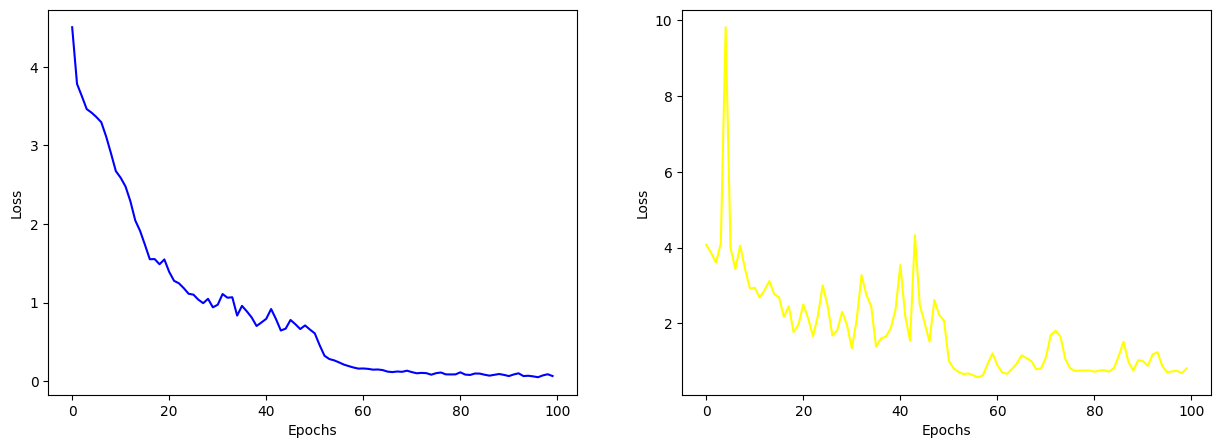

In [55]:
fig,ax = plt.subplots(1,2,figsize=(15,5))

ax[0].plot(np.arange(epochs),train_losses,label="Train loss",color="blue")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss")
ax[1].plot(np.arange(epochs),val_losses,label="Val loss",color="yellow")
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Loss")

In [56]:
# Evaluation

val_loss = evaluate(model,val_loader,criterion,device)
test_loss = evaluate(model,test_loader,criterion,device)
print(f"Validation loss: {val_loss:.4f}")
print(f"Test loss: {test_loss:.4f}")

Validation loss: 0.8115
Test loss: 1.1755


In [57]:
# Save model

save_model_path = "ocr_crnn.pt"
torch.save(model.state_dict(),save_model_path)

In [77]:
import locale
locale.setlocale(locale.LC_ALL, "C.UTF-8")


'C.UTF-8'

NotImplementedError: A UTF-8 locale is required. Got ANSI_X3.4-1968

In [85]:
import gdown

url = "https://drive.google.com/file/d/1jp3YpNR_eWSQnrELZjXTHsJjbMzNFB6W/view?usp=sharing"
output_path = 'ocr_crnn_base_best.pt'
gdown.download(url, output_path, quiet=False,fuzzy=True)

Downloading...
From (original): https://drive.google.com/uc?id=1jp3YpNR_eWSQnrELZjXTHsJjbMzNFB6W
From (redirected): https://drive.google.com/uc?id=1jp3YpNR_eWSQnrELZjXTHsJjbMzNFB6W&confirm=t&uuid=57adeaa8-80da-4da3-b684-77188db8bb8b
To: /content/ocr_crnn_base_best.pt
100%|██████████| 194M/194M [00:05<00:00, 34.6MB/s]


'ocr_crnn_base_best.pt'

In [58]:
text_det_model_path = "runs/detect/train3/weights/best.pt"
yolo = YOLO(text_det_model_path)

In [86]:
class CRNN(nn.Module):
  def __init__(self,vocab_size,hidden_size,n_layers,dropout=0.2,unfreeze_layers=3):
    super(CRNN,self).__init__()
    backbone = timm.create_model("resnet101",in_chans=1,pretrained=True)
    modules = list(backbone.children())[:-2]
    modules.append(nn.AdaptiveAvgPool2d((1,None)))
    self.backbone = nn.Sequential(*modules)
    for parameter in self.backbone[-unfreeze_layers:].parameters():
      parameter.require_grad = True

    self.mapSeq = nn.Sequential(
        nn.Linear(2048,512),
        nn.ReLU(),
        nn.Dropout(dropout)
    )

    self.lstm = nn.LSTM(
        512,hidden_size,
        n_layers,bidirectional=True,
        batch_first=True,
        dropout=dropout if n_layers > 1 else 0
    )
    self.layer_norm = nn.LayerNorm(hidden_size*2)
    self.out = nn.Sequential(
        nn.Linear(hidden_size*2,vocab_size),
        nn.LogSoftmax(dim=2)
    )
  def forward(self,x):
    x = self.backbone(x)
    x = x.permute(0,3,1,2)
    x = x.view(x.size(0),x.size(1),-1)
    x = self.mapSeq(x)
    x,_ = self.lstm(x)
    x = self.layer_norm(x)
    x = self.out(x)
    x = x.permute(1,0,2)
    return x
chars = "0123456789abcdefghijklmnopqrstuvwxyz-"
vocab_size = len(chars)
char_to_idx = {char:idx+1 for idx, char in enumerate(sorted(chars))}
idx_to_char = {idx:char for char,idx in char_to_idx.items()}
hidden_size=256
n_layers = 3
dropout_prob = 0.2
unfreeze_layers = 3
device = "cuda" if torch.cuda.is_available() else "cpu"
model_path = "ocr_crnn_base_best.pt"

crnn_model = CRNN(
    vocab_size=vocab_size,
    hidden_size=hidden_size,
    n_layers=n_layers,
    dropout=dropout_prob,
    unfreeze_layers=unfreeze_layers
).to(device)
crnn_model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [61]:
def decode(encoded_sequences,idx_to_char,blank_char="-"):
  decoded_sequences = []

  for seq in encoded_sequences:
    decoded_label = []
    for idx,token in enumerate(seq):
      if token !=0:
        char = idx_to_char[token.item()]
        if char != blank_char:
          decoded_label.append(char)
    decoded_sequences.append("".join(decoded_label))
  return decoded_sequences

In [62]:
def text_detection(img_path,text_det_model):
  text_det_results = text_det_model(img_path,verbose=False)[0]

  bboxes = text_det_results.boxes.xyxy.tolist()
  classes = text_det_results.boxes.cls.tolist()
  scores = text_det_results.boxes.conf.tolist()
  names = text_det_results.names
  return bboxes,classes,names,scores

In [63]:
def text_recognition(img,data_transforms,text_reg_model,idx_to_char,device):
  transformed_image =data_transforms(img)
  transformed_image = transformed_image.unsqueeze(0).to(device)
  text_reg_model.eval()
  with torch.no_gred():
    logits = text_reg_model(transformed_image).detach().cpu()
  text = decode(logits.permute(1,0,2).argmax(2),idx_to_char)
  return text

In [87]:
def visualize_detections(img,detections):
  plt.figure(figsize=(12,8))
  plt.imshow(img)
  plt.axis("off")

  for bbox,detected_class,confidence,transcribed_text in detections:
    x1,y1,x2,y2 = bbox
    plt.gca().add_patch(plt.Rectangle((x1,y1),x2-x1,y2-y1,fill=False,edgecolor="red",linewidth=2))
    plt.text(
        x1,y1-10,f"{detected_class} ({confidence:.2f}): {transcribed_text}",
        fontsize=9,bbox=dict(facecolor="red",alpha=0.5)
    )
  plt.show()

In [88]:
data_transforms = {
    "train":transforms.Compose([
        transforms.Resize((100,420)),
        transforms.ColorJitter(
            brightness = 0.5,
            contrast = 0.5,
            saturation = 0.5
        ),
        transforms.Grayscale(
            num_output_channels =1
        ),
        transforms.GaussianBlur(3),
        transforms.RandomAffine(
            degrees=1,
            shear=1
        ),
        transforms.RandomPerspective(
            distortion_scale=0.3,
            p=0.5,
            interpolation=3
        ),
        transforms.RandomRotation(degrees=2)
        ,transforms.ToTensor(),
        transforms.Normalize((0.5,),(0.5,))
    ]),
    "val":transforms.Compose([
        transforms.Resize((100,420)),
        transforms.Grayscale(
            num_output_channels =1
        )
        ,transforms.ToTensor(),
        transforms.Normalize((0.5,),(0.5,))
    ])
}

In [66]:
def predict(img_path,data_transforms,text_det_model,text_reg_model,idx_to_char,device):
  bboxes,classes,names,confs = text_detection(img_path,text_det_model)

  img = Image.open(img_path)

  predictions = []

  for bbox,cls,conf in zip(bboxes,classes,confs):
    x1,y1,x2,y2 = bbox
    confidence = conf
    detected_class = cls
    name = names[int(cls)]

    cropped_image = img.crop((x1,y1,x2,y2))

    transcribed_text = text_recognition(cropped_image,data_transforms,text_reg_model,idx_to_char,device)
    predictions.append([bbox,detected_class,confidence,transcribed_text])
  visualize_detections(img,predictions)
  return predictions